Projeto PI - Entrega (E2) - Análise dos Efeitos
Ana Beatriz Barbosa Yoshida
RA 245609

Importando as bibliotecas e verificação da CPU:

In [64]:
import torch
import torchvision
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Criação do Dataset e Dataloader: padronizando o tamanho das imagens

In [65]:
transformacoes = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])
caminho_dados = './dataset'
dataset = datasets.ImageFolder(root=caminho_dados, transform=transformacoes)

print(f"Total de fotos no dataset: {len(dataset)}")
print(f"Efeitos encontrados (Classes): {dataset.classes}")

dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

Total de fotos no dataset: 7686
Efeitos encontrados (Classes): ['175807_futuro', '175807_maria_e_sobel', '175807_pixelular', '186629_canny_edge_detection', '186629_chromatic_aberration_blur', '186629_color_splash', '237310_aberracao_cromatica', '237310_pixelizacao', '237310_quantizacao', '241163_chromatic_aberration', '241163_edge_detection', '241163_pixelation', '243360_chromatic_aberration', '243360_edge_detection', '243360_radial_blur', '245609_borda_lapis', '245609_fisheye', '245609_onda_de_calor', '245760_aberracao_cromatica', '245760_deteccao_borda', '245760_dithering', '246955_color_mapping', '246955_fish_eye', '246955_restricted_chromatic_aberration_and_vignette', '247145_border_detection', '247145_color_selection', '247145_twirl', '257234_blueprint_effect', '257234_gloomy_effect', '257234_industrial_effect', '260382_delete_later', '260382_difference_of_gaussians_flow', '260382_difference_of_gaussians_flow_less', '260382_dithering_black_white', '260382_dithering_red_black_white

Teste inicial para conferir se as imagens estão sendo processadas

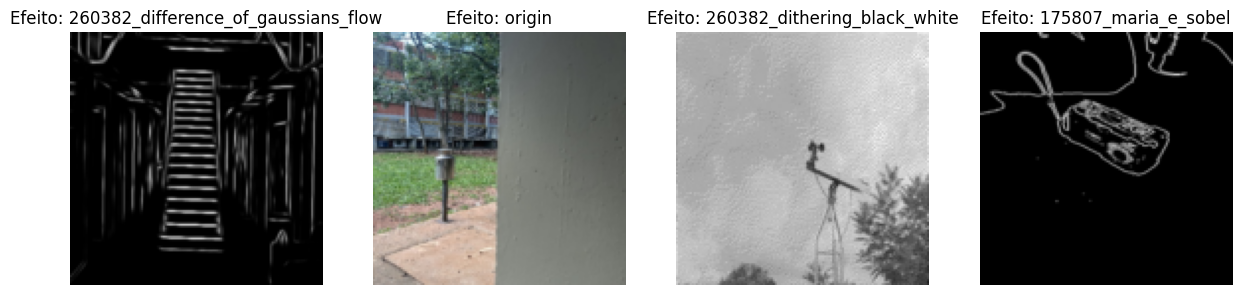

In [66]:
def mostrar_lote(imagens, labels, classes):
    fig, axes = plt.subplots(1, 4, figsize=(15, 5))
    for i in range(4):
        img = np.transpose(imagens[i].numpy(), (1, 2, 0))
        axes[i].imshow(img)
        axes[i].set_title(f"Efeito: {classes[labels[i]]}")
        axes[i].axis('off')
    plt.show()

#Pega um lote de imagens do dataloader e mostra
imagens_batch, labels_batch = next(iter(dataloader))
mostrar_lote(imagens_batch, labels_batch, dataset.classes)

Análise não supervisionada com PCA: Análise de componentens principais


Fotos analisadas: 7686. Colunas (Pixels): 49152


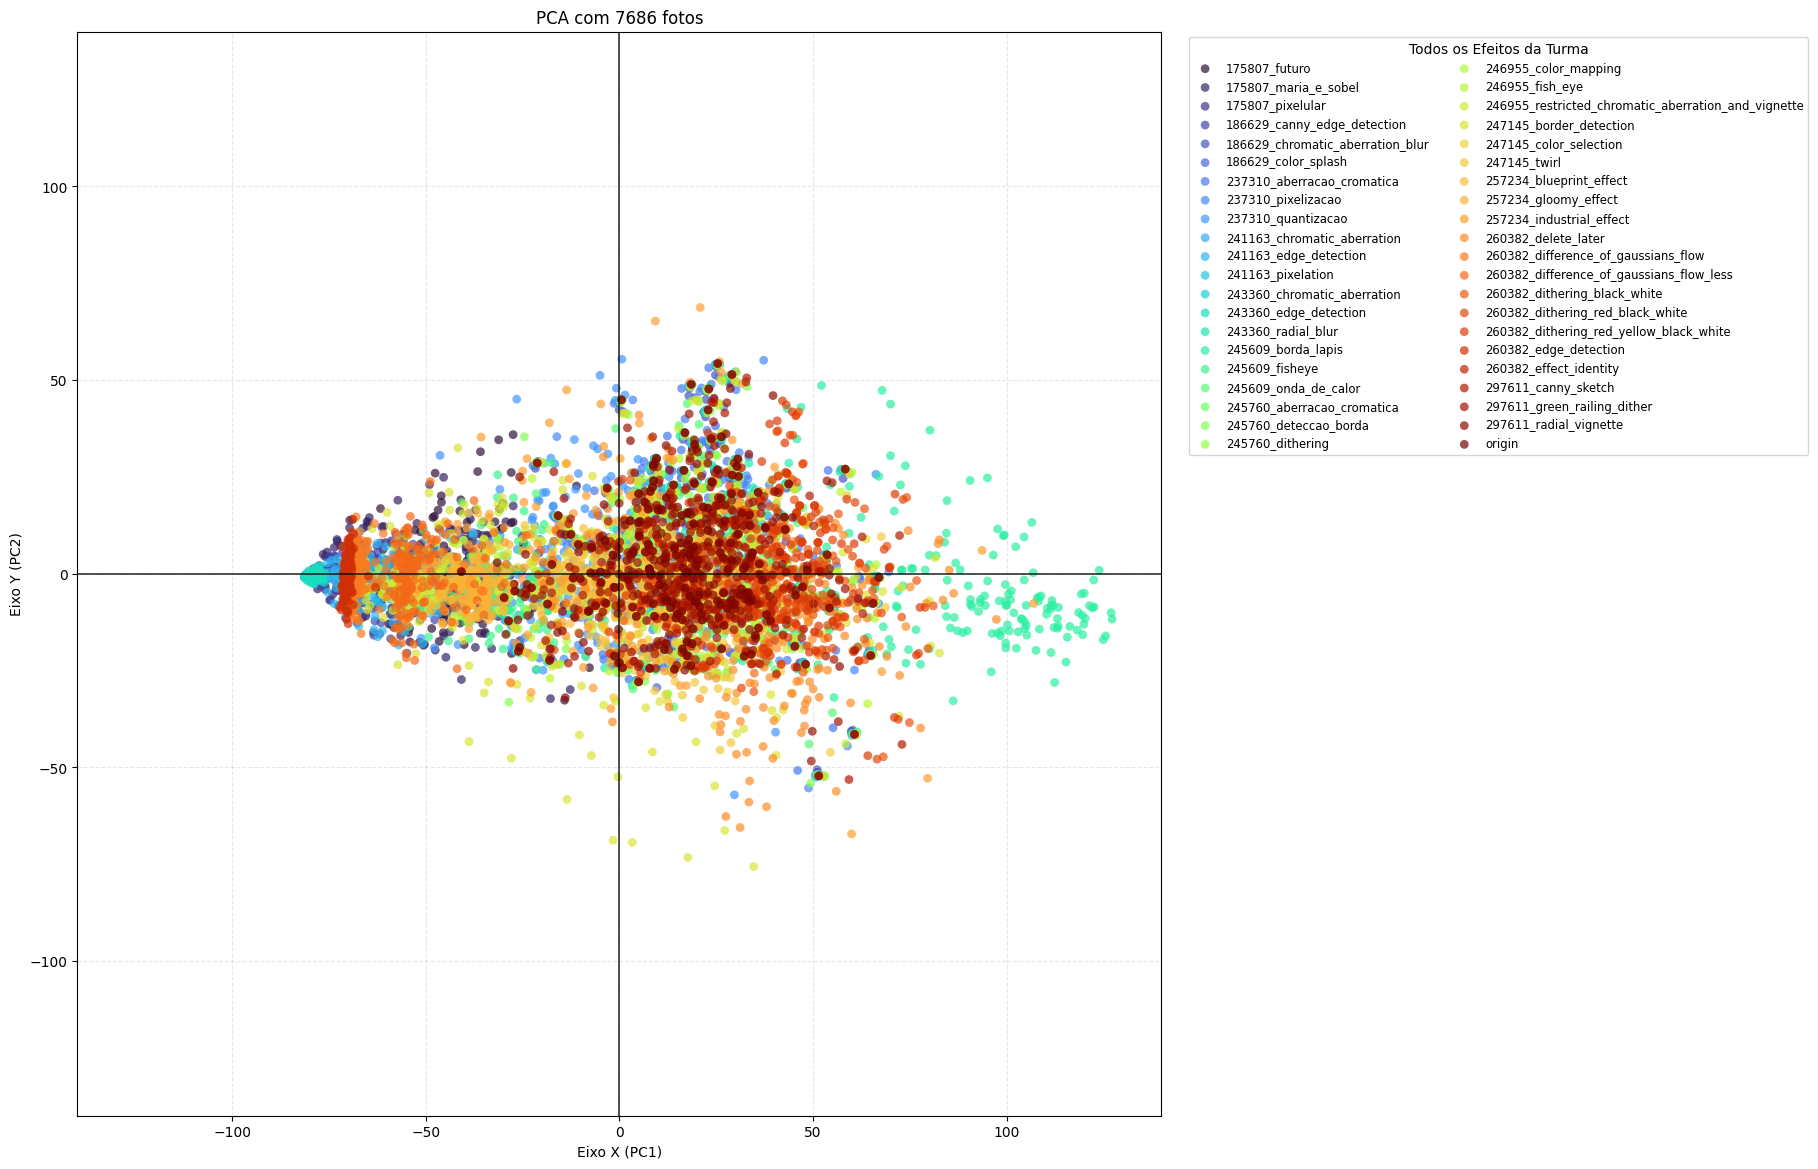

In [67]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

todas_imagens = []
todos_labels = []
fotos_processadas = 0
max_fotos = 7686

for imagens, labels in dataloader:
    if fotos_processadas >= max_fotos:
        break
    batch_achatado = imagens.view(imagens.size(0), -1).numpy()
    todas_imagens.append(batch_achatado)
    todos_labels.extend(labels.numpy())
    fotos_processadas += len(imagens)


X = np.vstack(todas_imagens)
y = np.array(todos_labels)

print(f"Fotos analisadas: {X.shape[0]}. Colunas (Pixels): {X.shape[1]}")

#aplicando PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
plt.figure(figsize=(16, 12)) 
paleta = plt.get_cmap('turbo', len(dataset.classes))


#plotando o gráfico
for i, nome_efeito in enumerate(dataset.classes):
    fotos_desse_efeito = (y == i) 
    plt.scatter(X_pca[fotos_desse_efeito, 0], X_pca[fotos_desse_efeito, 1], 
                label=nome_efeito, color=paleta(i), alpha=0.7, edgecolors='none', s=40)
plt.axhline(y=0, color='black', linewidth=1.2, linestyle='-', alpha=0.8) 
plt.axvline(x=0, color='black', linewidth=1.2, linestyle='-', alpha=0.8)

limite_max = np.max(np.abs(X_pca))
limite_max = limite_max * 1.1
plt.xlim(-limite_max, limite_max)
plt.ylim(-limite_max, limite_max)
plt.gca().set_aspect('equal', adjustable='box')
plt.legend(title="Todos os Efeitos da Turma", bbox_to_anchor=(1.02, 1), 
           loc='upper left', fontsize='small', ncol=2)

plt.title(f"PCA com {X_pca.shape[0]} fotos")
plt.xlabel("Eixo X (PC1)")
plt.ylabel("Eixo Y (PC2)")
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout() 
plt.show()

In [68]:
#Gráfico interativo para reconhecer os efeitos
import plotly.express as px
import pandas as pd
import numpy as np

nomes_dos_efeitos = [dataset.classes[label] for label in y]
df = pd.DataFrame({
    'Eixo X (PC1)': X_pca[:, 0],
    'Eixo Y (PC2)': X_pca[:, 1],
    'Efeito': nomes_dos_efeitos
})
fig = px.scatter(df, x='Eixo X (PC1)', y='Eixo Y (PC2)', color='Efeito', 
                 title="Análise PCA Interativa",
                 opacity=0.7)

limite_max = np.max(np.abs(X_pca)) * 1.1 
fig.update_xaxes(range=[-limite_max, limite_max], zeroline=True, zerolinewidth=2, zerolinecolor='black')
fig.update_yaxes(range=[-limite_max, limite_max], zeroline=True, zerolinewidth=2, zerolinecolor='black')

fig.update_layout(width=1000, height=800)
fig.show()

O modelo utilizado tem como base comprimir dados de alta dimensionalidade em poucas dimensões mas preservando informações relevantes. No caso do nosso dataset, as imagens possuem dimensionalidade [128,128,3]. Para analisarmos as imagens com o método de PCA, primeiramente, precisamos transformar essas dimensões em um vetor para que, depois, possamos agrupar todas essas imagens na matriz X. Então, utiliza-se da biblioteca PCA para que o código faça as operações necessárias e nos retorne as compenentes principais, que, segundo o modelo PCA, nos trará o maior nível de informações relevantes compactadas em duas dimensões.
O código foi rodado algumas vezes variando o número de fotos analisadas. Percebe-se que quanto maior o número de fotos, mais "agrupamentos" de efeitos aparecem no gráfico, o que demonstra que quanto mais fotos, mais parâmetros similiares dos efeitos o modelo consegue detectar.
Além disso, é possível analisar quais efeitos foram melhores detectados pelo modelo. Percebe-se, pelo gráfico, que alguns efeitos foram agrupados de forma mais assertiva. Como por exemplo, o efeito "260382_edge_detection" está quase todo no mesmo valor de x, assim como o efeito "260382_difference_of_gaussians_flow" ao analiser visualmente esses efeitos, percebe-se que ambos retornam imagens com fundo preto e detecção de bordas brancas. Em contra partida, o efeito "245609_borda_lapis" está no extremo oposto do eixo x, e, de fato, tal efeito retorna imagens com fundo branco e detecção de bordas pretas.
Desse modo, percebe-se algumas limitações desse modelo. Os efeitos mais bem agrupados foram aqueles que as variâncias de cor (preto/branco) eram mais marcantes. Porém, efeitos que utilizam cores, efeitos não-lineares como twirl e fish-eye ficaram dispersos ao longo do gráfico, o que significa que as compenentes principais levaram em contas alguns atributos e excluíram outros. 
Com isso, o PCA pode ser válido para analisar alguns tipos de imagem bem como identificar imagens com características opostas a partir da posição dos pontos no gráfico. Porém, não traz muitas informações quando se trata de outros parâmetros igualmente relevantes.


MODELO 2: APRENDIZADO SUPERVISIONADO CNN

Importando bibliotecas e definindo quantidade de imagens para treino e teste:

In [69]:
from torch.utils.data import random_split

tamanho_total = len(dataset)
tamanho_treino = int(0.8 * tamanho_total) 
tamanho_teste = tamanho_total - tamanho_treino

dataset_treino, dataset_teste = random_split(dataset, [tamanho_treino, tamanho_teste])

loader_treino = DataLoader(dataset_treino, batch_size=32, shuffle=True)
loader_teste = DataLoader(dataset_teste, batch_size=32, shuffle=False)

print(f"Número de fotos para treino: {len(dataset_treino)}")
print(f"Número de fotos para teste {len(dataset_teste)}")

Número de fotos para treino: 6148
Número de fotos para teste 1538


Definindo a arquitetura do sistema: camadas de convolução, pooling e decisões. Obs: rodado na placa de vídeo local

In [70]:

import torch.nn as nn
import torch.nn.functional as F
import torch

class RedeEfeitos(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1) #lê o canal de cores e aplica 16 filtros
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2) #camada de pooling
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1) #segunda camada de convolução
        
        self.fc1 = nn.Linear(32 * 32 * 32, 128)
        self.fc2 = nn.Linear(128, num_classes)  

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x))) 
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        
        x = F.relu(self.fc1(x))
        x = self.fc2(x)        
        return x

numero_de_efeitos = len(dataset.classes)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"{device}")
modelo = RedeEfeitos(num_classes=numero_de_efeitos).to(device)

mps


Laços de treinamento do modelo:

In [71]:
import torch.optim as optim

criterio = nn.CrossEntropyLoss() 
otimizador = optim.Adam(modelo.parameters(), lr=0.001) 
numero_de_etapas = 6 
historico_erros = []

for etapa in range(numero_de_etapas):
    modelo.train() 
    erro_acumulado = 0.0

    for imagens, labels in loader_treino:
        imagens = imagens.to(device)
        labels = labels.to(device)
        otimizador.zero_grad()
        previsoes = modelo(imagens)
        erro = criterio(previsoes, labels)
        erro.backward() 
        otimizador.step()
        
        
        erro_acumulado += erro.item()
        
    erro_medio = erro_acumulado / len(loader_treino)
    historico_erros.append(erro_medio)
    
    print(f"Etapa {etapa+1}/{numero_de_etapas}: Erro Médio: {erro_medio:.4f}")

Etapa 1/6: Erro Médio: 2.3568
Etapa 2/6: Erro Médio: 1.4308
Etapa 3/6: Erro Médio: 1.0798
Etapa 4/6: Erro Médio: 0.8508
Etapa 5/6: Erro Médio: 0.6589
Etapa 6/6: Erro Médio: 0.5766


Avaliação do modelo com as fotos de teste:

In [72]:
acertos = 0
total_fotos = 0
modelo.eval()

with torch.no_grad():
    for imagens, labels in loader_teste:
        imagens = imagens.to(device)
        labels = labels.to(device)
        previsoes = modelo(imagens)
        _, adivinhacao = torch.max(previsoes, 1)
        total_fotos += labels.size(0)
        acertos += (adivinhacao == labels).sum().item()
acuracia = 100 * acertos / total_fotos
print(f"Acertos: {acertos} de {total_fotos} fotos.")
print(f"Acurácia do Modelo: {acuracia:.2f}%")

Acertos: 1026 de 1538 fotos.
Acurácia do Modelo: 66.71%


Matriz de confusão para análise de erros:

In [ ]:
#Matriz de confusão interativa
from sklearn.metrics import confusion_matrix
import plotly.express as px

todas_previsoes = []
todos_gabaritos = []

modelo.eval()
with torch.no_grad():
    for imagens, labels in loader_teste:
        imagens = imagens.to(device)
        labels = labels.to(device)
        previsoes = modelo(imagens)
        _, adivinhacao = torch.max(previsoes, 1)
        todas_previsoes.extend(adivinhacao.cpu().numpy())
        todos_gabaritos.extend(labels.cpu().numpy())
nomes_efeitos = dataset.classes
matriz = confusion_matrix(todos_gabaritos, todas_previsoes)
fig = px.imshow(matriz,
                labels=dict(x="Previsão", y="Efeito", color="Quantidade de Fotos"),
                x=nomes_efeitos,
                y=nomes_efeitos,
                color_continuous_scale='Magma',
                title="Matriz de Confusão")
fig.update_layout(width=1000, height=1000, xaxis_tickangle=-45)
fig.show()

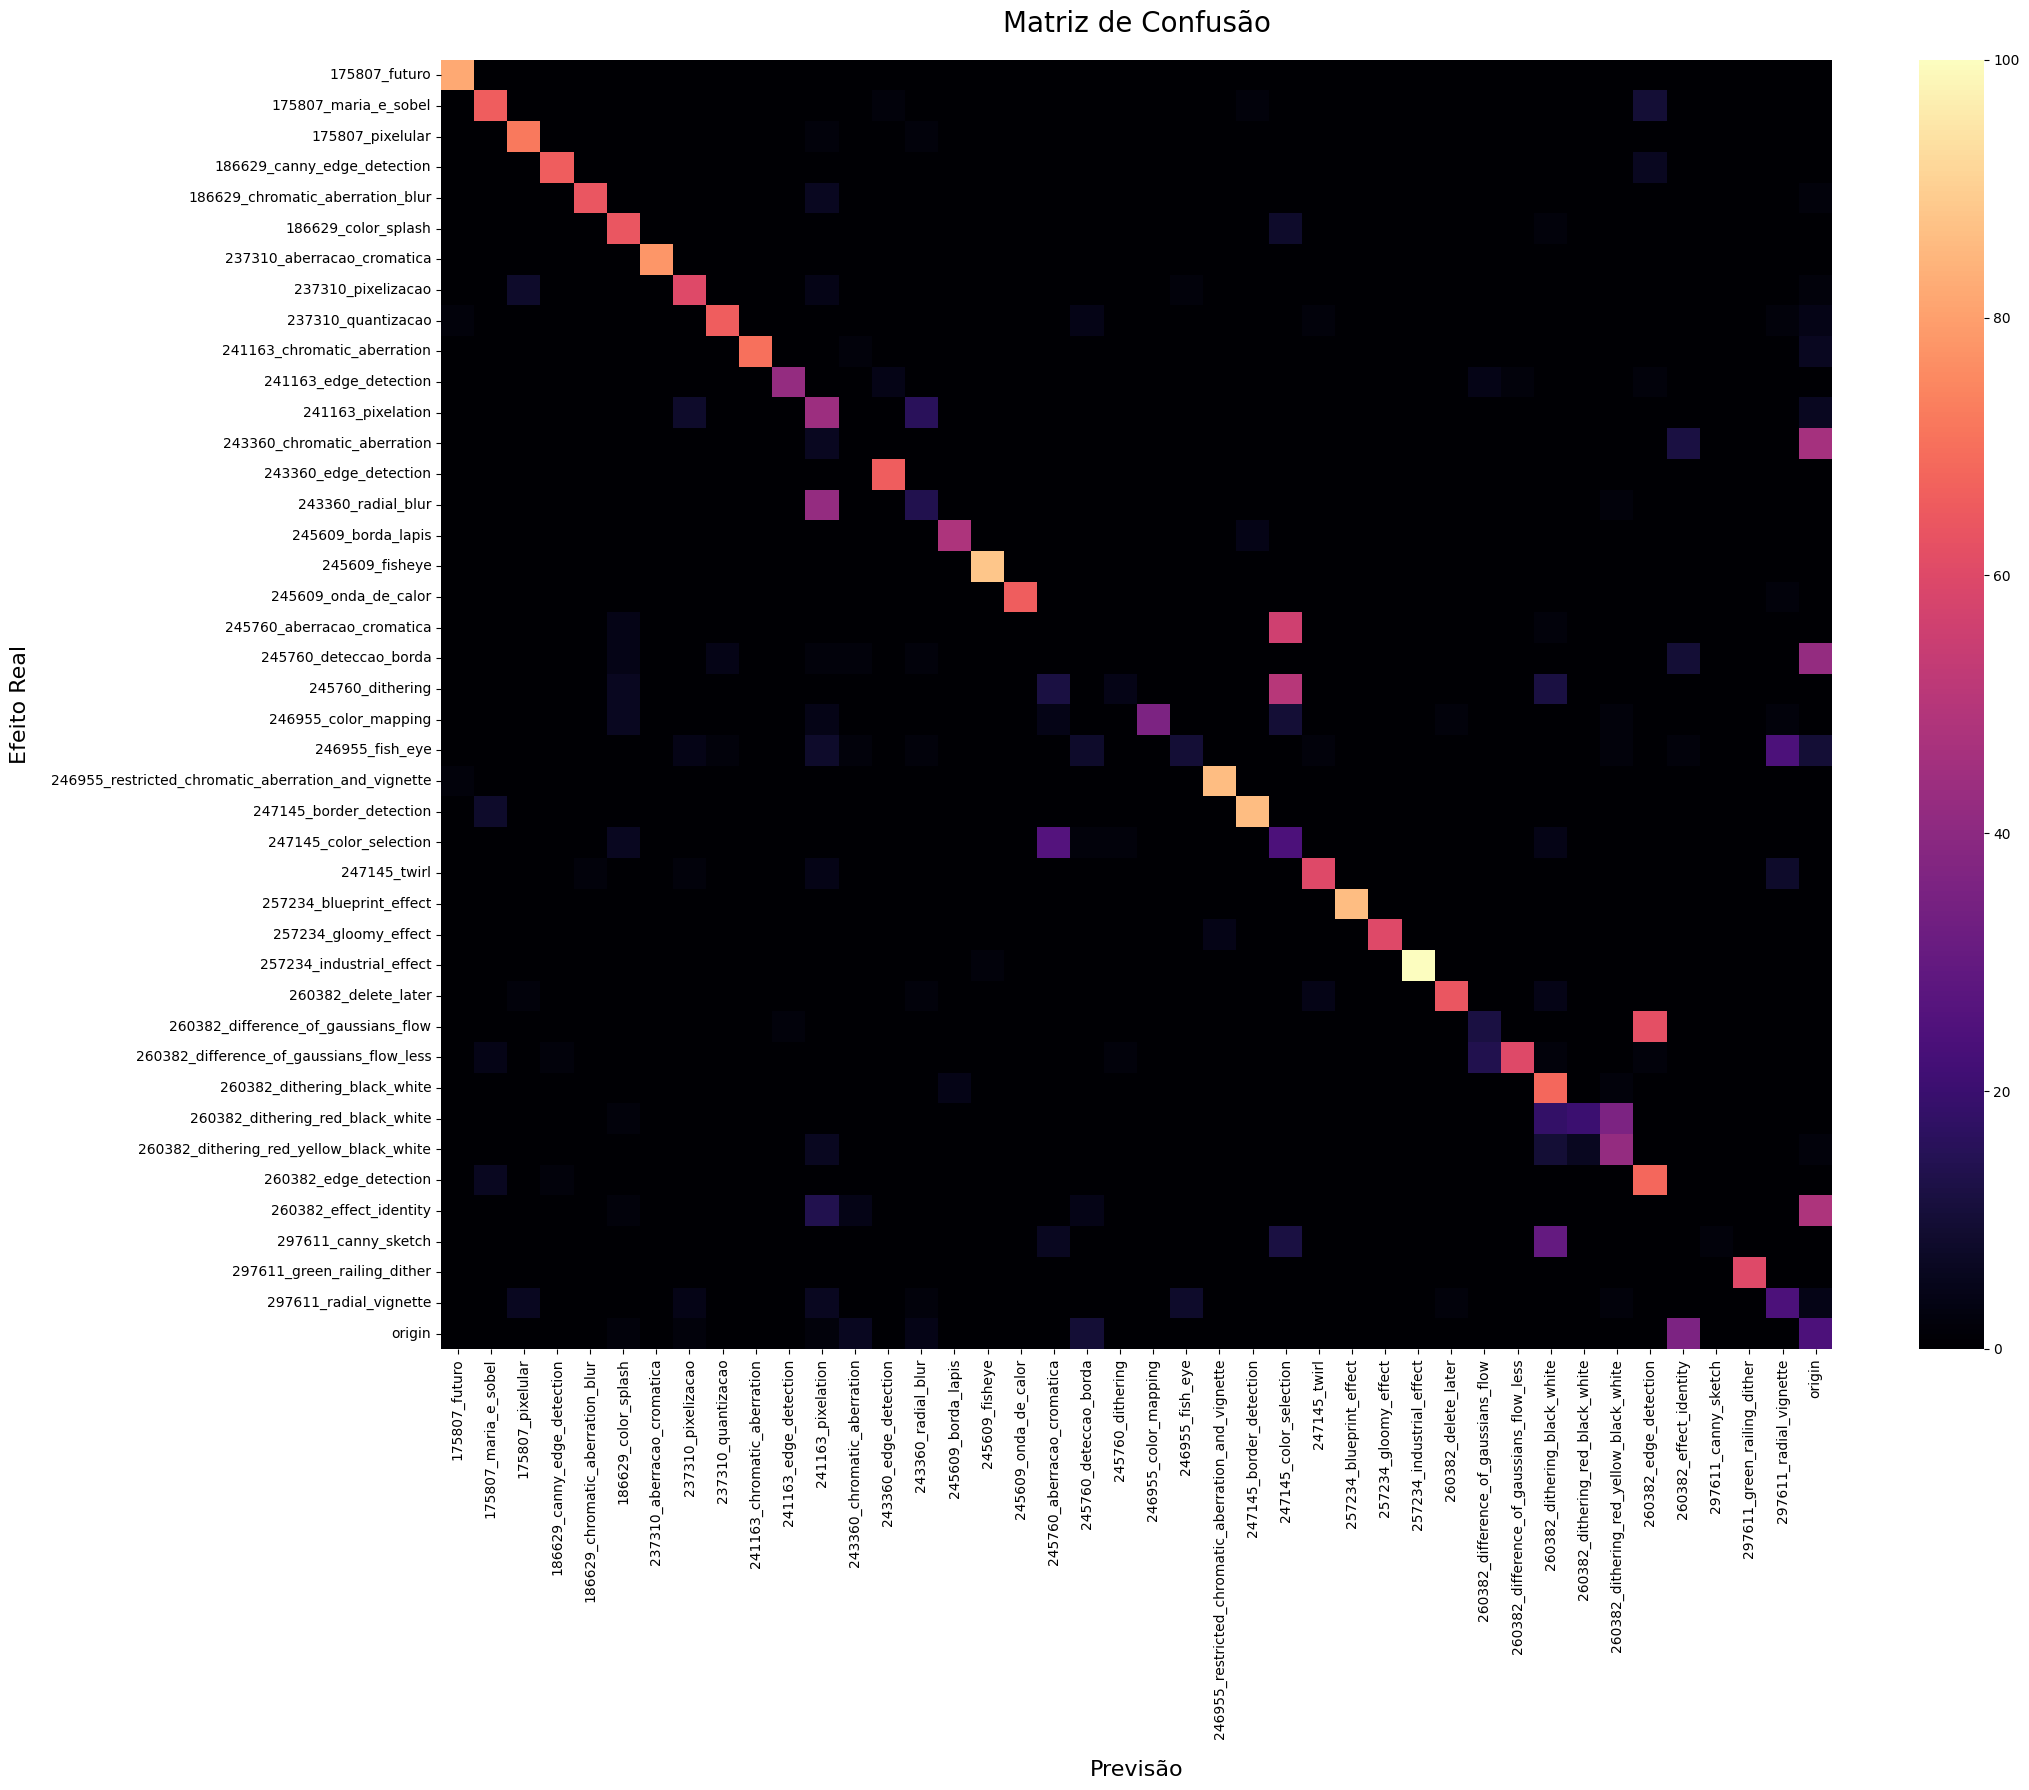

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import torch
modelo.eval()
with torch.no_grad():
    for imagens, labels in loader_teste:
        imagens = imagens.to(device)
        labels = labels.to(device)
        
        previsoes = modelo(imagens)
        _, adivinhacao = torch.max(previsoes, 1)
        
        todas_previsoes.extend(adivinhacao.cpu().numpy())
        todos_gabaritos.extend(labels.cpu().numpy())

matriz = confusion_matrix(todos_gabaritos, todas_previsoes)
nomes_efeitos = dataset.classes
plt.figure(figsize=(22, 18)) 

mapa = sns.heatmap(matriz, annot=False, cmap='magma', 
                   xticklabels=nomes_efeitos, yticklabels=nomes_efeitos)

plt.title("Matriz de Confusão", fontsize=20, pad=20)
plt.xlabel("Previsão", fontsize=16, labelpad=15)
plt.ylabel("Efeito Real", fontsize=16, labelpad=15)
plt.xticks(rotation=90, fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout() 
plt.show()

O método CNN é um um método linear supervisionado que funciona a partir da aplicação kernels, camadas de convolução, pooling e camadas conectadas. Além disso, ela funciona com aprendizado em etapas, a cada etapa, é calculado o tamanho do erro e as camadas que causaram esse erro são corrigidas, com isso, a taxa de erro diminui a cada etapa. O algoritmo foi rodado algumas vezes variando o número de etapas e, de fato, a acurácia do modelo aumenta quanto maior o número de etapas.
Porém, os erros do modelo podem ser analisados a partir dos efeitos gerados. Com a matriz de confusão, observa-se que os efeitos "241163_pixelation" e "237310_pixelacao" foram confundidos pelo modelo, ao analisar ambos efeitos, percebe-se que são quase impercetíveis a olho humano por se tratarem da mesma técnica de pixelação das imagens. A mesma semelhança de efeitos acontece para efeitos de dithering.  Ademais, embora o dataset tenha sido eficiente para treinar o modelo, um banco de dados maior nos traria maior acurácia pois também foi observado que quanto maior a quantidade de fotos separadas para treinamento, menores foram os erros.
Ao comparar com o modelo anterior PCA não supervisionado, o modelo CNN garante melhores resultados a medida que não apenas devolve as respostas, ao invés de agrupar fotos parecidas, mas também por ser rodada em etapas que corrigem e diminuem seus erros. Uma observação a ser feito é que, para os efeitos "260382_edge_detection" e "260382_difference_of_gaussians_flow" o método CNN os confundiou bastante, mas, ao reparar o gráfica do PCA, esse efeitos estão muito próximos um do ou outro no eixo x, o que demonstra que retornam imagens bem parecidas. 
Com isso, concluímos que podemos usar o PCA e o CNN de formas complementares na análise de dados. O PCA nos da informações sobre similaridades e diferenças de características relevantes enquanto o CNN é mais eficaz em identificar padrões de imagem e os rotular.